Title: capacity_data_onshore.ipynb

Purpose: Transform the xml capacity data into some gridded format

Author: Onno Nennecke on 10.02.2025 Modified: 11.03.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [1]:
import pandas as pd
import geopandas as gpd
import xml.etree.ElementTree as ET
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import Functions.grid_func as grid_func # Own function to create 1x1 degree grid

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
# Load the XML file
tree = ET.parse('/climca/people/onennecke/Wind_Solar_MaStR/EinheitenWind.xml')
root = tree.getroot()


Felder relevant:
columns_to_keep = ['EinheitMastrNummer', 'Postleitzahl', 'Bruttoleistung', 'Nettonennleistung',
  'Lage', 'NameWindpark', 'Nabenhoehe', 'Rotordurchmesser', 
  'Seelage', 'ClusterNordsee', 'Wassertiefe', 'Kuestenentfernung', 'ClusterOstsee', 'Laengengrad',
  'Breitengrad']

Liste Felder nicht relevant:
columns_to_loose = ['DatumLetzteAktualisierung', 'LokationMaStRNummer',
       'NetzbetreiberpruefungStatus', 'AnlagenbetreiberMastrNummer', 'Land', 
       'Bundesland', 'Landkreis', 'Gemeinde', 'Gemeindeschluessel', 'Ort',
       'Registrierungsdatum', 'Inbetriebnahmedatum', 'EinheitSystemstatus',
       'EinheitBetriebsstatus', 'NichtVorhandenInMigriertenEinheiten',
       'NameStromerzeugungseinheit', 'Weic_nv', 'Kraftwerksnummer_nv',
       'Energietraeger', 'FernsteuerbarkeitNb', 'Einspeisungsart', 'EegMaStRNummer',
       'DatumBeginnVoruebergehendeStilllegung', 'NetzbetreiberpruefungDatum',
       'Adresszusatz', 'FernsteuerbarkeitDv', 'DatumDesBetreiberwechsels',
       'DatumRegistrierungDesBetreiberwechsels', 'Gemarkung', 'FlurFlurstuecknummern',
       'AnschlussAnHoechstOderHochSpannung', 
       'DatumEndgueltigeStilllegung', 'Strasse', 'StrasseNichtGefunden', 'Hausnummer_nv',
       'HausnummerNichtGefunden',
       'GenMastrNummer', 'Einsatzverantwortlicher', 'WeicDisplayName',
       'DatumWiederaufnahmeBetrieb', 'GeplantesInbetriebnahmedatum',
       'Buergerenergie', 'Kraftwerksnummer','Hersteller', 'Technologie', 'Typenbezeichnung',
       'Rotorblattenteisungssystem', 'AuflageAbschaltungLeistungsbegrenzung',
       'AuflagenAbschaltungSchallimmissionsschutzNachts',
       'AuflagenAbschaltungSchallimmissionsschutzTagsueber',
       'AuflagenAbschaltungSchattenwurf', 'AuflagenAbschaltungTierschutz',
       'AuflagenAbschaltungEiswurf', 'AuflagenAbschaltungSonstige',
       'Nachtkennzeichnung','Hausnummer']

In [3]:
rows = []

for einheit in root.findall('EinheitWind'):
        einheit_data = {
            'EinheitMastrNummer': einheit.find('EinheitMastrNummer').text,
            'Postleitzahl': einheit.find('Postleitzahl').text if einheit.find('Postleitzahl') is not None else np.nan,
            'Bruttoleistung': float(einheit.find('Bruttoleistung').text),
            'Nettonennleistung': float(einheit.find('Nettonennleistung').text),
            'Lage': int(einheit.find('Lage').text) if einheit.find('Lage') is not None else np.nan,
            'NameWindpark': einheit.find('NameWindpark').text if einheit.find('NameWindpark') is not None else np.nan,
            'Nabenhoehe': float(einheit.find('Nabenhoehe').text) if einheit.find('Nabenhoehe') is not None else np.nan,
            'Rotordurchmesser': float(einheit.find('Rotordurchmesser').text) if einheit.find('Rotordurchmesser') is not None else np.nan,
            'Laengengrad': float(einheit.find('Laengengrad').text) if einheit.find('Laengengrad') is not None else np.nan,
            'Breitengrad': float(einheit.find('Breitengrad').text) if einheit.find('Breitengrad') is not None else np.nan,
            'EinheitBetriebsstatus': int(einheit.find('EinheitBetriebsstatus').text)
        }
        rows.append(einheit_data)


# Convert the list of dictionaries to a DataFrame
df = pd.DataFrame(rows)

# Display the resulting DataFrame
# print(df)

In [4]:
# Drop closed units
print(len(df[df['EinheitBetriebsstatus'] != 35]))
df_1 = df[df['EinheitBetriebsstatus'] == 35].copy() # 35 == In Betrieb

# Drop off-shore units
df_2 = df_1[df_1['Lage'] != 889].copy()

# Drop columns EinheitBetriebsstatus and Lage as they are no longer needed
df_2.drop(columns=['EinheitBetriebsstatus', 'Lage'], inplace=True)

6689


In [ ]:
# Manually fill in missing postal codes
df_2[df_2['Postleitzahl'].isna()]

plz_mapping = {
    'SEE936808217954': '06406',
    'SEE968754227626': '49762',
    'SEE955273809822': '49762',
    'SEE948208029693': '54675'
}

df_2['Postleitzahl'] = df_2.apply(
    lambda row: plz_mapping[row['EinheitMastrNummer']] if pd.isna(row['Postleitzahl']) and row['EinheitMastrNummer'] in plz_mapping else row['Postleitzahl'],
    axis=1
)

In [6]:
# Some data inspection

df_2['Nabenhoehe'].describe()

# df_2['Rotordurchmesser'].describe()

# df_2['Bruttoleistung'].describe()

# df_2['Nettonennleistung'].describe()

count    29038.000000
mean        98.613275
std         35.038866
min          1.000000
25%         70.000000
50%         98.350000
75%        135.000000
max        173.480000
Name: Nabenhoehe, dtype: float64

In [ ]:
# # Count the number of NaN values in the 'column_name' column
# nan_count_plz = df_2['Postleitzahl'].isna().sum()
# print(f"Count of NaN values in 'Postleitzahl': {nan_count_plz}")

# nan_count_co = df_2['Breitengrad'].isna().sum()
# print(f"Count of NaN values in 'Breitengrad': {nan_count_co}")

# # But cancel each other out:
# print(len(df_2[df_2['Breitengrad'].notna() | df_2['Postleitzahl'].notna()]))
# print(len(df_2[df_2['Breitengrad'].isna() & df_2['Postleitzahl'].isna()]))

Count of NaN values in 'Postleitzahl': 0
Count of NaN values in 'Breitengrad': 916
29749
0


In [8]:
# Create centroids
# Lade eine Shapefile mit PLZ-Geometrien (z.B. aus OpenStreetMap oder von Statistikbehörden)
plz_shp = gpd.read_file("/climca/people/onennecke/PLZ_Germany/OSM_PLZ.shp")

# Daten mit PLZ-Zentroiden verknüpfen
plz_shp["geometry"] = plz_shp.geometry.centroid

# Reproject data
gdf_latlong = plz_shp.to_crs(epsg=4326)

# print(gdf_latlong.crs)

gdf_latlong['x'] = gdf_latlong['geometry'].x
gdf_latlong['y'] = gdf_latlong['geometry'].y
gdf_latlong

plz_df = gdf_latlong[["plz", "geometry", "x", "y"]]
# plz_df

In [ ]:
# list_plz_nd = set(df_2["Postleitzahl"]) - set(plz_df["plz"])    # These PLZs are not in the PLZ shapefile

# print('There are', len(set(df_2["Postleitzahl"])), 'unique plz in the dataset. \n', 
#     'There are', len(set(plz_df["plz"])), 'PLZs in the reference PLZ shapefile. \n',
#     len(list_plz_nd), 'of the plzs in the dataset are not in the PLZ shapefile --> Outdated \n',
#     'These are:', list_plz_nd, '\n',
#     'These', len(list_plz_nd), 'plzs occur', len(df_2[df_2['Postleitzahl'].isin(list_plz_nd)]), 'times in the dataset. \n',
#     'There are', len(set(plz_df["plz"]) - set(df_2["Postleitzahl"])), 'PLZs in the PLZ shapefile but not in the dataset. \n')

There are 2773 unique plz in the dataset. 
 There are 8170 PLZs in the reference PLZ shapefile. 
 0 of the plzs in the dataset are not in the PLZ shapefile --> Outdated 
 These are: set() 
 These 0 plzs occur 0 times in the dataset. 
 There are 5397 PLZs in the PLZ shapefile but not in the dataset. 



In [11]:
# Group by PLZ
grouped = df_2.groupby('Postleitzahl').agg({'Bruttoleistung': 'sum', 'Nettonennleistung': 'sum', 'Nabenhoehe':'mean', 'Rotordurchmesser':'mean'}).reset_index()
# grouped

In [12]:
# Merge the two DataFrames
merged_df = pd.merge(grouped, plz_df, left_on='Postleitzahl', right_on='plz')

merged_df = gpd.GeoDataFrame(merged_df, geometry=merged_df.geometry)
merged_df.drop(columns=['plz'], inplace=True)
# type(merged_df)
# merged_df

In [ ]:
# Save current data for further use
# merged_df.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_plz.shp')

/tmp/ipykernel_2853147/3018087337.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_df.to_file('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_plz.shp')
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Postleitzahl' to 'Postleitza'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Bruttoleistung' to 'Bruttoleis'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Nettonennleistung' to 'Nettonennl'
  ogr_write(
/home/onennecke/.conda/envs/on_ma_env/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'Rotordurchmesser' to 'Rotordurch'
  ogr_write(


In [ ]:
# Create a grid
grid = grid_func.create_ref_grid('wind_on_cap')
# grid

In [ ]:
# Change coordinates to grid coordinates
merged_df["lat_idx"] = np.searchsorted(grid['lat'], merged_df["y"]) # Zeilenindex für Latitude
merged_df["lon_idx"] = np.searchsorted(grid['lon'], merged_df["x"]) # Spaltenindex für Longitude

# merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,Nabenhoehe,Rotordurchmesser,geometry,x,y,lat_idx,lon_idx
0,01454,6400.0,6400.0,73.000000,54.800000,POINT (13.91345 51.14013),13.913446,51.140132,5,9
1,01561,1.0,1.0,7.200000,2.700000,POINT (13.63389 51.29631),13.633891,51.296306,5,9
2,01594,37400.0,37400.0,135.145455,119.454545,POINT (13.29018 51.25891),13.290177,51.258906,5,9
3,01609,40900.0,40900.0,124.687500,101.750000,POINT (13.42529 51.39129),13.425295,51.391292,5,9
4,01612,19100.0,19100.0,148.876000,126.000000,POINT (13.4084 51.29573),13.408405,51.295729,5,9
...,...,...,...,...,...,...,...,...,...,...
2768,99955,83150.0,83150.0,128.225806,107.000000,POINT (10.83291 51.16642),10.832915,51.166422,5,6
2769,99958,36000.0,36000.0,100.000000,80.545455,POINT (10.75165 51.09204),10.751649,51.092040,5,6
2770,99976,16519.6,16519.6,78.375000,50.281250,POINT (10.33357 51.25391),10.333567,51.253907,5,6
2771,99988,600.0,600.0,46.000000,43.000000,POINT (10.26928 51.17095),10.269281,51.170951,5,6


In [49]:
# print(merged_df['x'].min())
# print(merged_df['x'].max())

# print(merged_df['y'].min())
# print(merged_df['y'].max())

# Wurde nicht richtig geplottet (nur durch shift um 0.5) --> Problem mit den edges/centers
# merged_df[(merged_df['lat_idx'] == 4) & (merged_df['lon_idx'] == 8)]

# print(merged_df['lat_idx'].min())
# print(merged_df['lat_idx'].max())

# print(merged_df['lon_idx'].min())
# print(merged_df['lon_idx'].max())

In [15]:
grid_sums = merged_df.groupby(["lat_idx", "lon_idx"])["Bruttoleistung"].sum()
# grid_sums

In [ ]:
# Write the sums to the grid
for (lat_idx, lon_idx), value in grid_sums.items():
    grid[lat_idx, lon_idx] = value

# Show resulting grid
# print(grid)

<xarray.DataArray 'wind_on_cap' (lat: 10, lon: 12)> Size: 960B
array([[           nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan,
                   nan,            nan,            nan,            nan],
       [           nan,            nan,            nan, 3.11140000e+04,
        6.07935000e+04, 1.46146000e+04, 1.18591720e+05, 1.20738000e+04,
        3.98000000e+01,            nan,            nan,            nan],
       [           nan,            nan,            nan, 6.42333000e+04,
        2.60346500e+05, 2.83080300e+05, 3.97544973e+05, 1.44431770e+05,
        1.88142800e+04, 8.91640000e+02,            nan,            nan],
       [           nan,            nan, 8.34996400e+05, 1.66449670e+06,
        9.00908900e+05, 9.68041300e+05, 7.79613175e+05, 6.12911820e+05,
        6.77958500e+04,            nan,            nan,            nan],
       [           nan,            nan, 1.62096270e+06, 9.52281300e+0

In [17]:
# Save grid as raster file
grid.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')

In [18]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid

<xarray.Dataset> Size: 1kB
Dimensions:      (lat: 10, lon: 12)
Coordinates:
  * lat          (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
  * lon          (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    crs          int64 8B ...
Data variables:
    wind_on_cap  (lat, lon) float64 960B ...

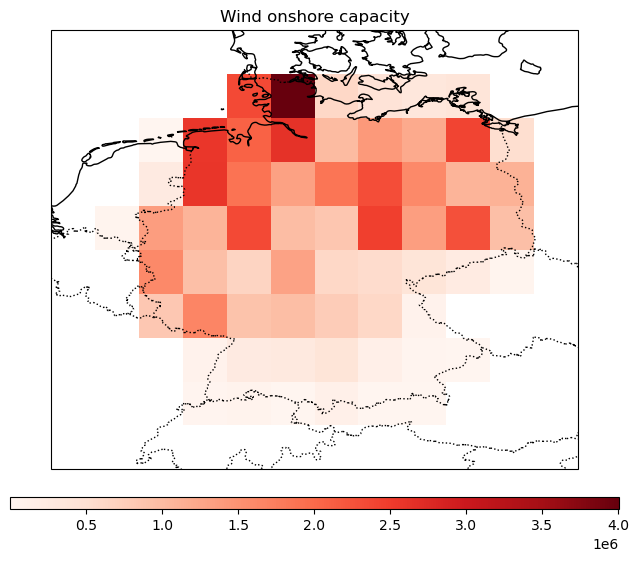

In [19]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_on_cap'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind onshore capacity')

plt.tight_layout()
plt.show()

## Hub Height calculation

In [20]:
# Drop data without height values
df_3 = df_2.dropna(subset=['Nabenhoehe'])
df_3

,EinheitMastrNummer,Postleitzahl,Bruttoleistung,Nettonennleistung,NameWindpark,Nabenhoehe,Rotordurchmesser,Laengengrad,Breitengrad
0,SEE940146675093,34298,3000.0,3000.0,Windpark Kreuzstein,149.08,115.710,9.739374,51.270068
1,SEE973767078653,23824,3000.0,3000.0,Damsdorf,135.40,115.700,10.299400,54.073831
2,SEE914108319653,34298,3000.0,3000.0,Windpark Kreuzstein,149.08,115.710,9.733069,51.272164
3,SEE982417853618,34298,3000.0,3000.0,Windpark Kreuzstein,149.08,115.710,9.748361,51.270462
4,SEE913741454097,52525,2400.0,2400.0,Windpark Heinsberg Pütt,120.00,116.800,6.045546,51.029548
...,...,...,...,...,...,...,...,...,...
37722,SEE925893699196,26969,10.0,10.0,Butjadingen privat,8.00,4.400,NaN,NaN
37747,SEE961246009564,02625,1.0,1.0,WKA SkyWind Auritz,7.00,1.509,NaN,NaN
37940,SEE965066246611,71159,0.6,0.6,Kleinwindrad 2024 Zeppelinstraße,8.00,1.510,NaN,NaN
38028,SEE945872382253,84494,1.0,1.0,Westwind,3.40,2.100,NaN,NaN


In [21]:
def weighted_mean(df, value_column, weight_column):
    return np.average(df[value_column], weights=df[weight_column])

# Group by 'Postleitzahl' and apply the custom aggregation
grouped = df_3.groupby('Postleitzahl').apply(
    lambda x: pd.Series({
        'Bruttoleistung': x['Bruttoleistung'].sum(),
        'Nettonennleistung': x['Nettonennleistung'].sum(),
        'Nabenhoehe': weighted_mean(x, 'Nabenhoehe', 'Bruttoleistung'),
        'Rotordurchmesser': x['Rotordurchmesser'].mean()
    })
).reset_index()

grouped

# Display the descriptive statistics for the 'Nabenhoehe' column
print(grouped['Nabenhoehe'].describe())

count    2688.000000
mean       97.490724
std        39.495127
min         1.200000
25%        71.665679
50%       100.962397
75%       130.760413
max       169.375000
Name: Nabenhoehe, dtype: float64


/tmp/ipykernel_1722318/1297430499.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_3.groupby('Postleitzahl').apply(


In [22]:
# Merge the two DataFrames
merged_df = pd.merge(grouped, plz_df, left_on='Postleitzahl', right_on='plz')

merged_df = gpd.GeoDataFrame(merged_df, geometry=merged_df.geometry)
merged_df.drop(columns=['plz'], inplace=True)
# type(merged_df)
merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,Nabenhoehe,Rotordurchmesser,geometry,x,y
0,01454,6400.0,6400.0,79.375000,54.800000,POINT (13.91345 51.14013),13.913446,51.140132
1,01561,1.0,1.0,7.200000,2.700000,POINT (13.63389 51.29631),13.633891,51.296306
2,01594,37400.0,37400.0,135.130481,119.454545,POINT (13.29018 51.25891),13.290177,51.258906
3,01609,40900.0,40900.0,127.740831,101.750000,POINT (13.42529 51.39129),13.425295,51.391292
4,01612,19100.0,19100.0,152.653089,126.000000,POINT (13.4084 51.29573),13.408405,51.295729
...,...,...,...,...,...,...,...,...
2683,99955,83150.0,83150.0,134.363199,107.000000,POINT (10.83291 51.16642),10.832915,51.166422
2684,99958,36000.0,36000.0,100.000000,80.545455,POINT (10.75165 51.09204),10.751649,51.092040
2685,99976,16515.0,16515.0,91.649712,50.281250,POINT (10.33357 51.25391),10.333567,51.253907
2686,99988,600.0,600.0,46.000000,43.000000,POINT (10.26928 51.17095),10.269281,51.170951


In [ ]:
# Create a grid
grid_height = grid_func.create_ref_grid('wind_on_hub_height')
# grid_height

In [24]:
# Wandle Koordinaten in das Grid-Koordinatensystem
merged_df["lat_idx"] = np.searchsorted(grid_height['lat'], merged_df["y"]) # Zeilenindex für Latitude
merged_df["lon_idx"] = np.searchsorted(grid_height['lon'], merged_df["x"]) # Spaltenindex für Longitude

merged_df

,Postleitzahl,Bruttoleistung,Nettonennleistung,Nabenhoehe,Rotordurchmesser,geometry,x,y,lat_idx,lon_idx
0,01454,6400.0,6400.0,79.375000,54.800000,POINT (13.91345 51.14013),13.913446,51.140132,5,9
1,01561,1.0,1.0,7.200000,2.700000,POINT (13.63389 51.29631),13.633891,51.296306,5,9
2,01594,37400.0,37400.0,135.130481,119.454545,POINT (13.29018 51.25891),13.290177,51.258906,5,9
3,01609,40900.0,40900.0,127.740831,101.750000,POINT (13.42529 51.39129),13.425295,51.391292,5,9
4,01612,19100.0,19100.0,152.653089,126.000000,POINT (13.4084 51.29573),13.408405,51.295729,5,9
...,...,...,...,...,...,...,...,...,...,...
2683,99955,83150.0,83150.0,134.363199,107.000000,POINT (10.83291 51.16642),10.832915,51.166422,5,6
2684,99958,36000.0,36000.0,100.000000,80.545455,POINT (10.75165 51.09204),10.751649,51.092040,5,6
2685,99976,16515.0,16515.0,91.649712,50.281250,POINT (10.33357 51.25391),10.333567,51.253907,5,6
2686,99988,600.0,600.0,46.000000,43.000000,POINT (10.26928 51.17095),10.269281,51.170951,5,6


In [25]:
grid_mean_height = merged_df.groupby(["lat_idx", "lon_idx"]).apply(
    lambda x: np.average(x["Nabenhoehe"], weights=x["Bruttoleistung"])
)
grid_mean_height

/tmp/ipykernel_1722318/3044045027.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grid_mean_height = merged_df.groupby(["lat_idx", "lon_idx"]).apply(


lat_idx  lon_idx
1        3          146.361767
         4          141.908883
         5          110.945459
         6          119.697092
         7          148.277525
                       ...    
8        5           98.707945
         6           95.241284
         7           85.362578
         8           95.880737
         9          101.360401
Length: 63, dtype: float64

In [26]:
# Schritt 4: Werte ins Grid schreiben
for (lat_idx, lon_idx), value in grid_mean_height.items():
    grid_height[lat_idx, lon_idx] = value

# Resultierendes Grid anzeigen
print(grid_height)

<xarray.DataArray 'wind_on_hub_height' (lat: 10, lon: 12)> Size: 960B
array([[         nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan,
                 nan,          nan,          nan,          nan],
       [         nan,          nan,          nan, 146.36176684,
        141.90888311, 110.94545865, 119.69709201, 148.27752468,
         34.33668342,          nan,          nan,          nan],
       [         nan,          nan,          nan, 134.5675416 ,
        126.68288325, 131.55115493, 131.96980489, 129.93191545,
        108.53215558,  52.32503634,          nan,          nan],
       [         nan,          nan, 127.52311213, 130.90730447,
        129.80752111, 129.80694309, 134.74138818, 136.5544478 ,
        130.33715577,          nan,          nan,          nan],
       [         nan,          nan, 111.43261677, 124.68611208,
        133.14502041, 134.55598532, 125.52868   , 127.55340363,
        123.24655684,  85.7706

In [27]:
# Save grid as raster file
grid_height.to_netcdf('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')

In [28]:
grid = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid

<xarray.Dataset> Size: 1kB
Dimensions:             (lat: 10, lon: 12)
Coordinates:
  * lat                 (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
  * lon                 (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    crs                 int64 8B ...
Data variables:
    wind_on_hub_height  (lat, lon) float64 960B ...

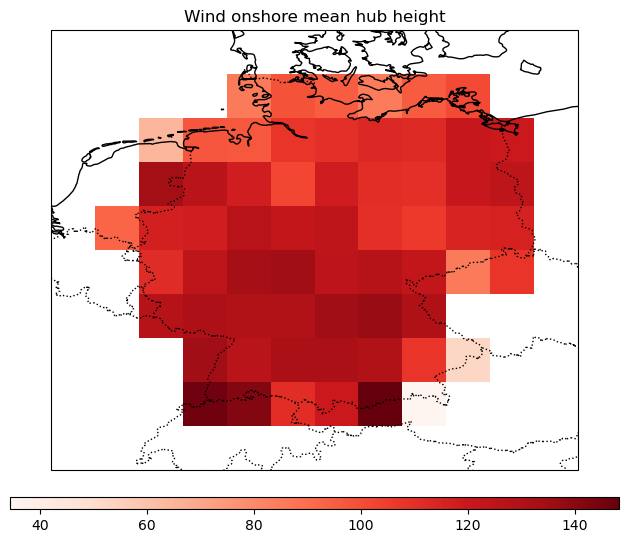

In [29]:
lon_edges = grid.lon.values - (grid.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid.lat.values - (grid.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

# Plot the data

fig = plt.figure(figsize=(9, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# First subplot
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
im = ax.pcolormesh(lon_edges, lat_edges, grid['wind_on_hub_height'], transform=ccrs.PlateCarree(), cmap='Reds')
cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax.set_title('Wind onshore mean hub height')

plt.tight_layout()
plt.show()